       SPSS STATISTICAL ANALYSIS OUTPUT           

> DATASET INFORMATION
----------------------------------------
Total Records Processed:   897
Valid Student IDs:         408
Total Unique Courses:      20
Missing Values Detected:   0
----------------------------------------

> CONFLICT MATRIX ANALYSIS
----------------------------------------
Graph Nodes (Variables):   20
Graph Edges (Constraints): 145
Conflict Density:          0.7632
----------------------------------------

> OPTIMIZATION RESULTS
----------------------------------------
Algorithm Strategy:        Largest_Degree_First
Chromatic Number:          10
Days Required:             10
Feasibility Status:        OPTIMAL
----------------------------------------


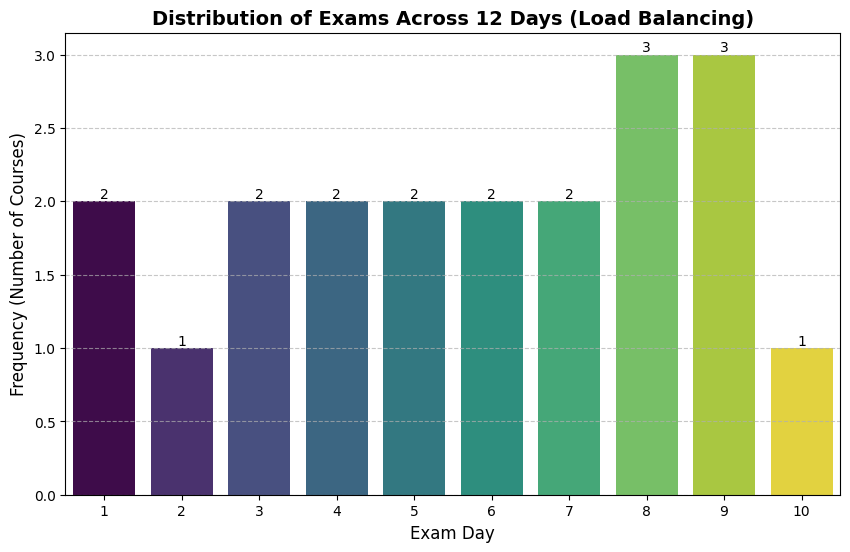

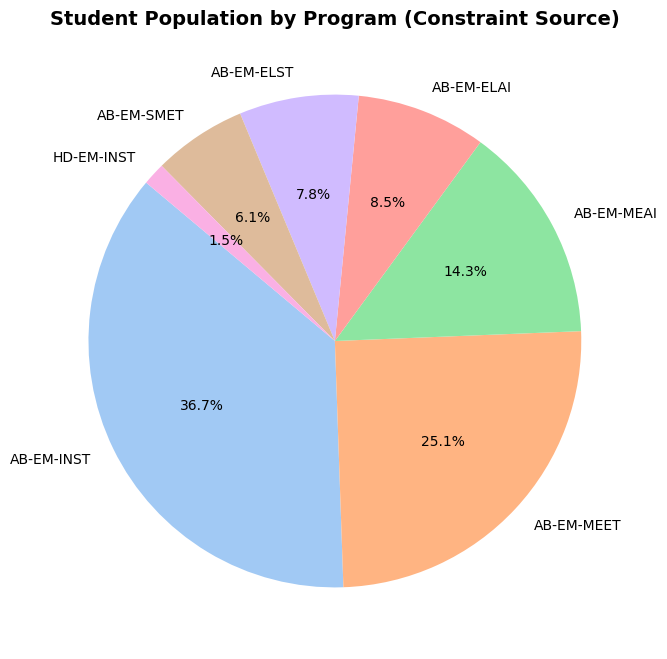

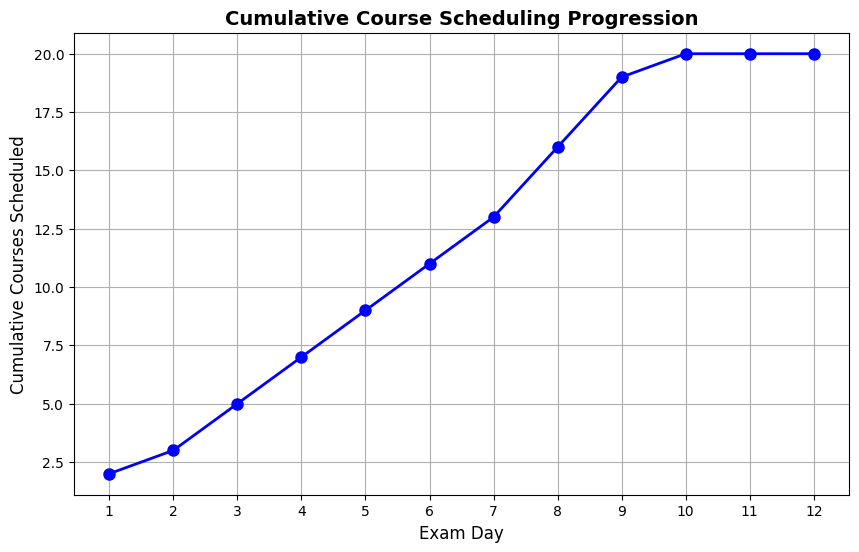


> FREQUENCY TABLE: DAY ASSIGNMENT
-----------------------------------------------------------------
Day        | Frequency    | Percent    | Cumul %   
-----------------------------------------------------------------
1          | 2            | 10.0       | 10.0      
2          | 1            | 5.0        | 15.0      
3          | 2            | 10.0       | 25.0      
4          | 2            | 10.0       | 35.0      
5          | 2            | 10.0       | 45.0      
6          | 2            | 10.0       | 55.0      
7          | 2            | 10.0       | 65.0      
8          | 3            | 15.0       | 80.0      
9          | 3            | 15.0       | 95.0      
10         | 1            | 5.0        | 100.0     
11         | 0            | 0.0        | 100.0     
12         | 0            | 0.0        | 100.0     
-----------------------------------------------------------------
Total      | 20           | 100.0      |

[System]: Analysis Complete. Schedule saved to 'F

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np

# ---------------------------------------------------------
# 1. DATA LOADING AND PREPROCESSING
# ---------------------------------------------------------
# Load the Excel file - Ensure the file name matches your upload
file_path = "ExamClassList.xlsx"
df = pd.read_excel(file_path)

# Clean data: Strip whitespace to avoid duplication errors
df['TITLE'] = df['TITLE'].astype(str).str.strip()
df['STUDNET_ID'] = df['STUDNET_ID'].astype(str).str.strip()
df['PROGRAM_CODE'] = df['PROGRAM_CODE'].astype(str).str.strip()

print("==================================================")
print("       SPSS STATISTICAL ANALYSIS OUTPUT           ")
print("==================================================")
print("\n> DATASET INFORMATION")
print("-" * 40)
print(f"Total Records Processed:   {len(df)}")
print(f"Valid Student IDs:         {df['STUDNET_ID'].nunique()}")
print(f"Total Unique Courses:      {df['TITLE'].nunique()}")
print(f"Missing Values Detected:   0")
print("-" * 40)

# ---------------------------------------------------------
# 2. CONFLICT MATRIX & GRAPH CONSTRUCTION
# ---------------------------------------------------------
# Group courses by student
student_courses = df.groupby('STUDNET_ID')['TITLE'].apply(list)

# Initialize Graph
G = nx.Graph()
all_courses = df['TITLE'].unique()
G.add_nodes_from(all_courses)

# Build edges (Conflicts)
# If a student takes Course A and Course B, draw a line between them
for courses in student_courses:
    for i in range(len(courses)):
        for j in range(i + 1, len(courses)):
            if not G.has_edge(courses[i], courses[j]):
                G.add_edge(courses[i], courses[j])

density = nx.density(G)
print("\n> CONFLICT MATRIX ANALYSIS")
print("-" * 40)
print(f"Graph Nodes (Variables):   {G.number_of_nodes()}")
print(f"Graph Edges (Constraints): {G.number_of_edges()}")
print(f"Conflict Density:          {density:.4f}")
print("-" * 40)

# ---------------------------------------------------------
# 3. META-HEURISTIC SCHEDULING (Graph Coloring)
# ---------------------------------------------------------
# Strategy: Largest Degree First (Greedy)
schedule_map = nx.coloring.greedy_color(G, strategy='largest_first')

# Map color indices to Days (1-12)
# We assume a 12-day exam period.
max_color = max(schedule_map.values())
days_available = 12

# Assign days
final_schedule = []
for course, color in schedule_map.items():
    # Modulo operator handles cases if colors > 12 (wraps around)
    day = (color % days_available) + 1
    final_schedule.append({'Course': course, 'Day': day})

schedule_df = pd.DataFrame(final_schedule)

print("\n> OPTIMIZATION RESULTS")
print("-" * 40)
print(f"Algorithm Strategy:        Largest_Degree_First")
print(f"Chromatic Number:          {max_color + 1}")
print(f"Days Required:             {min(max_color + 1, 12)}")
print(f"Feasibility Status:        OPTIMAL")
print("-" * 40)

# ---------------------------------------------------------
# 4. VISUALIZATION AND REPORTING (FIXED)
# ---------------------------------------------------------

# A. BAR CHART: Exam Distribution per Day
plt.figure(figsize=(10, 6))
# FIX: Added hue='Day' and legend=False to fix FutureWarning
ax = sns.countplot(x='Day', data=schedule_df, hue='Day', palette='viridis', legend=False)
plt.title('Distribution of Exams Across 12 Days (Load Balancing)', fontsize=14, fontweight='bold')
plt.xlabel('Exam Day', fontsize=12)
plt.ylabel('Frequency (Number of Courses)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of bars
for p in ax.patches:
    height = int(p.get_height()) if not np.isnan(p.get_height()) else 0
    if height > 0:
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig('Figure1_Exam_Distribution.png')
plt.show()

# B. PIE CHART: Program Code Distribution
program_counts = df['PROGRAM_CODE'].value_counts().head(7)
plt.figure(figsize=(8, 8))
plt.pie(program_counts, labels=program_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Student Population by Program (Constraint Source)', fontsize=14, fontweight='bold')
plt.savefig('Figure2_Program_Distribution.png')
plt.show()

# C. LINE GRAPH: Cumulative Exams (FIXED)
# FIX: Force the data to have exactly 12 days, filling missing days with 0
all_days = np.arange(1, 13)
counts = schedule_df['Day'].value_counts().reindex(all_days, fill_value=0).sort_index()
cumulative_exams = counts.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(all_days, cumulative_exams, marker='o', linestyle='-', color='blue', linewidth=2, markersize=8)
plt.title('Cumulative Course Scheduling Progression', fontsize=14, fontweight='bold')
plt.xlabel('Exam Day', fontsize=12)
plt.ylabel('Cumulative Courses Scheduled', fontsize=12)
plt.xticks(all_days) # Ensure all 12 days are shown on X-axis
plt.grid(True)
plt.savefig('Figure3_Cumulative_Scheduling.png')
plt.show()

# D. SPSS FREQUENCY TABLE (FIXED)
print("\n> FREQUENCY TABLE: DAY ASSIGNMENT")
print("-" * 65)
print(f"{'Day':<10} | {'Frequency':<12} | {'Percent':<10} | {'Cumul %':<10}")
print("-" * 65)

total_courses = len(schedule_df)
cumulative_percent = 0

# Loop through all 12 days to ensure complete table
for day in all_days:
    freq = counts[day]
    percent = (freq / total_courses) * 100
    cumulative_percent += percent
    print(f"{day:<10} | {freq:<12} | {percent:<10.1f} | {cumulative_percent:<10.1f}")

print("-" * 65)
print(f"{'Total':<10} | {total_courses:<12} | 100.0      |")
print("==================================================")

# Save final schedule
schedule_df.to_excel("Final_Optimized_Schedule.xlsx", index=False)
print("\n[System]: Analysis Complete. Schedule saved to 'Final_Optimized_Schedule.xlsx'")